In [83]:
import torch

print(torch.backends.mps.is_available())

True


In [84]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [85]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords, wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping



In [86]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [87]:
import pandas as pd

df = pd.read_csv('/Users/charlotecalosor/Downloads/CLEANED(without Rating)_dataset.csv')

In [88]:
df

,Category,Label,Review
0,Home_and_Kitchen_5,CG,love this well made sturdy and very comfortab...
1,Home_and_Kitchen_5,CG,love it a great upgrade from the original ive...
2,Home_and_Kitchen_5,CG,this pillow saved my back i love the look and ...
3,Home_and_Kitchen_5,CG,missing information on how to use it but it is...
4,Home_and_Kitchen_5,CG,very nice set good quality we have had the set...
...,...,...,...
40406,Clothing_Shoes_and_Jewelry_5,OR,i had read some reviews saying that this bra r...
40407,Clothing_Shoes_and_Jewelry_5,CG,i wasnt sure exactly what it would be it is a ...
40408,Clothing_Shoes_and_Jewelry_5,OR,you can wear the hood by itself wear it with t...
40409,Clothing_Shoes_and_Jewelry_5,CG,i liked nothing about this dress the only reas...


In [89]:
df.tail()

,Category,Label,Review
40406,Clothing_Shoes_and_Jewelry_5,OR,i had read some reviews saying that this bra r...
40407,Clothing_Shoes_and_Jewelry_5,CG,i wasnt sure exactly what it would be it is a ...
40408,Clothing_Shoes_and_Jewelry_5,OR,you can wear the hood by itself wear it with t...
40409,Clothing_Shoes_and_Jewelry_5,CG,i liked nothing about this dress the only reas...
40410,Clothing_Shoes_and_Jewelry_5,OR,i work in the wedding industry and have to wor...


In [90]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['Review'].apply(clean_text)

In [91]:
print(df[['Review', 'clean_review']].head())

                                              Review  \
0  love this  well made sturdy and very comfortab...   
1  love it a great upgrade from the original  ive...   
2  this pillow saved my back i love the look and ...   
3  missing information on how to use it but it is...   
4  very nice set good quality we have had the set...   

                                        clean_review  
0  love this well made sturdy and very comfortabl...  
1  love it a great upgrade from the original ive ...  
2  this pillow saved my back i love the look and ...  
3  missing information on how to use it but it is...  
4  very nice set good quality we have had the set...  


In [92]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

df['clean_review'] = df['clean_review'].apply(remove_stopwords)

In [93]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_text(text):
    words = text.split()
    tagged = pos_tag(words)

    return ' '.join([
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
    ])

df['clean_review'] = df['clean_review'].apply(lemmatize_text)

In [94]:
y = df['Label'].values   # CHANGE this to your actual column name

In [95]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [96]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['clean_review'])

X = tokenizer.texts_to_sequences(df['clean_review'])
X = pad_sequences(X, maxlen=200)

In [97]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [98]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.regularizers import l2

model = Sequential([
    Embedding(input_dim=10001, output_dim=64),  # ↓ reduced embedding size

    Conv1D(32, 5, activation='relu', kernel_regularizer=l2(0.01)),  # ↓ smaller filters

    GlobalMaxPooling1D(),

    Dropout(0.6),  # stronger regularization

    Dense(16, activation='relu', kernel_regularizer=l2(0.02)),

    Dropout(0.6),

    Dense(1, activation='sigmoid')
])

In [99]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [100]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

In [101]:
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [102]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5951 - loss: 0.9357 - val_accuracy: 0.7642 - val_loss: 0.7030
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7706 - loss: 0.6056 - val_accuracy: 0.8560 - val_loss: 0.4671
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8406 - loss: 0.4790 - val_accuracy: 0.8669 - val_loss: 0.4122
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8629 - loss: 0.4303 - val_accuracy: 0.8679 - val_loss: 0.3906
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8773 - loss: 0.3957 - val_accuracy: 0.8671 - val_loss: 0.3777
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8884 - loss: 0.3694 - val_accuracy: 0.8671 - val_loss: 0.3707
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8966 - loss: 0.3496 - val_accuracy: 0.8674 - val_loss: 0.3708
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9018 - loss: 0.3326 - val_accuracy: 0.

In [103]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      2020
           1       0.89      0.86      0.88      2022

    accuracy                           0.88      4042
   macro avg       0.88      0.88      0.88      4042
weighted avg       0.88      0.88      0.88      4042



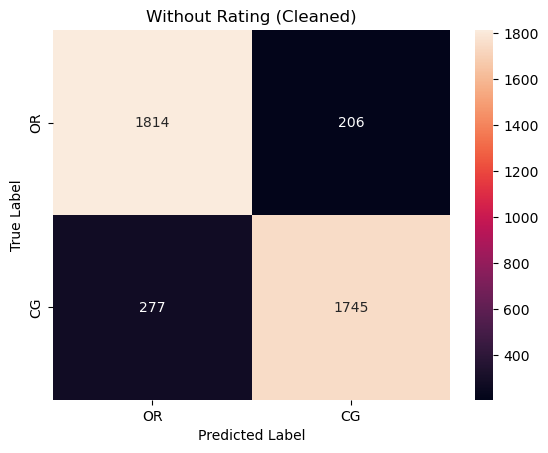

In [104]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["OR", "CG"]  # adjust if your encoding is reversed

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title("Without Rating (Cleaned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

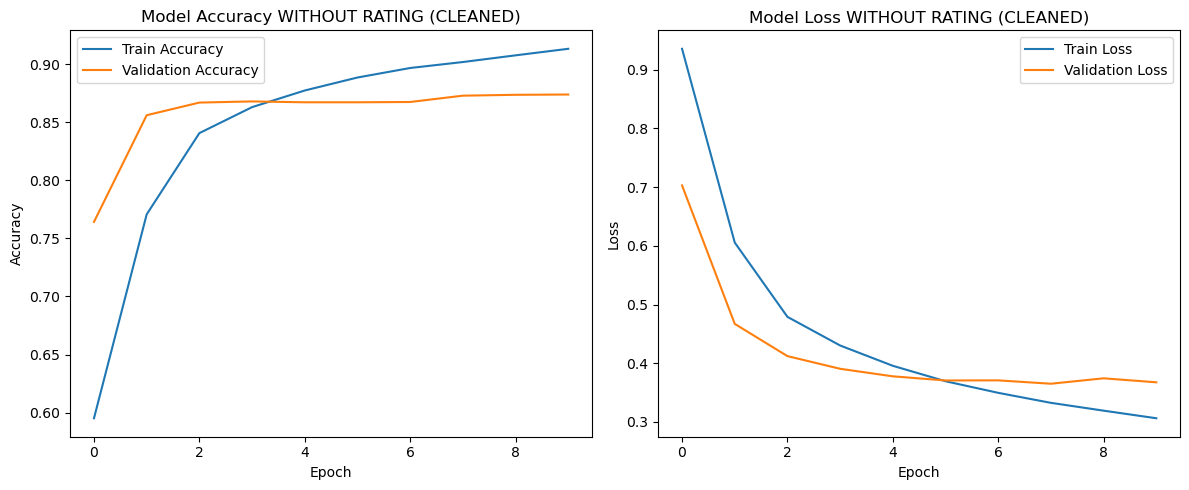

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy WITHOUT RATING (CLEANED)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss WITHOUT RATING (CLEANED)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [106]:
# Check what max length your model expects
print(model.input_shape)

(None, 200)


In [107]:
print(len(tokenizer.word_index))

41952


In [108]:
test_text = ["This product is absolutely amazing!"]
seq = tokenizer.texts_to_sequences(test_text)
print("Sequence:", seq)

Sequence: [[31, 251, 559]]


In [109]:
test_text = ["This product is absolutely amazing!"]
seq = tokenizer.texts_to_sequences(test_text)
padded = pad_sequences(seq, maxlen=model.input_shape[1])

print("Word index size:", len(tokenizer.word_index))
print("Sequence:", seq)
print("Padded shape:", padded.shape)
print("Padded values:", padded)

pred = model.predict(padded, verbose=0)
print("Raw prediction:", pred)

Word index size: 41952
Sequence: [[31, 251, 559]]
Padded shape: (1, 200)
Padded values: [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  31
  251 559]]
Raw prediction: [[0.4142916]]


In [130]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

while True:
    # Ask for input
    new_text = input("\nEnter a review: ")

    # Exit condition
    if new_text.lower() == 'exit':
        print("Program ended.")
        break

    # Preprocess
    new_seq = tokenizer.texts_to_sequences([new_text])
    new_padded = pad_sequences(new_seq, maxlen=model.input_shape[1])

    # Predict
    prediction = model.predict(new_padded, verbose=0)

    # Output label
    if prediction[0][0] > 0.5:
        print(f"Prediction: CG (Computer Generated) — confidence: {prediction[0][0]:.2%}")
    else:
        print(f"Prediction: OR (Original Review) — confidence: {1 - prediction[0][0]:.2%}")


Enter a review:  The functionality is great aligned with manufacturer specifications.


Prediction: OR (Original Review) — confidence: 58.57%



Enter a review:  The build quality is exceptional and the materials used feel very durable. It is a reliable choice for long-term use.


Prediction: CG (Computer Generated) — confidence: 80.92%



Enter a review:  This device is easy to operate it meets the specifications in the product description.


...

Prediction: CG (Computer Generated) — confidence: 61.53%



Enter a review:  This is my purchase of the month. Thanks seller


Prediction: OR (Original Review) — confidence: 58.57%



Enter a review:  exit


Program ended.
